# Support Ticket Classification & Priority Prediction Model
**Machine Learning Internship - Task 2**
**Student Name:** Thomas Debebe
**CIN:** FIT/APR26/ML7294

---

## 📌 Project Context
In a SaaS environment, support efficiency is critical for customer retention. This project automates the helpdesk workflow by using Natural Language Processing (NLP) to analyze incoming tickets, route them to the correct department, and assign an urgency level (Priority).

## 🛠️ Technical Workflow & Methodology

### 1. Text Preprocessing (Cleaning the Data)
To ensure the model focuses on meaning rather than noise, I implemented a cleaning pipeline:
* **Normalization:** Lowercasing all text and removing special characters/punctuation.
* **Stopword Removal:** Removing common words (e.g., "is", "the", "at") that don't contribute to the category intent.
* **Tokenization:** Breaking sentences down into individual word units for analysis.

### 2. Feature Extraction (TF-IDF)
I used **Term Frequency-Inverse Document Frequency (TF-IDF)**. Unlike simple word counts, TF-IDF weighs words by their importance. For example, the word "Login" is given a higher weight in **Technical Support** tickets than the word "Hello," which appears everywhere.

### 3. Classification Logic
* **Categorization:** I trained a classifier to distinguish between categories like *Billing*, *Technical Issue*, and *General Inquiry*.
* **Priority Decision:** I implemented logic to detect urgency markers. Tickets with terms like "Urgent," "Failed," "Blocked," or "Refund" are automatically escalated to **High Priority**, while general feedback is labeled as **Low**.

### 4. Evaluation Metrics
To validate the model for business use, I analyzed:
* **Accuracy & Precision:** Ensuring high reliability for automated routing.
* **Confusion Matrix:** A visual tool used to identify if the model is confusing "Inquiries" with "Technical" issues.

---

import pandas as pd
import nltk
from sklearn.model_selection import train_test_split

print("NLP tools and Pandas are ready to go!")

# Now let's load your ticket data
# Replace 'support_tickets.csv' with your actual file name if it's different!
df = pd.read_csv('it_support_tickets.csv')

# This shows us the first 5 rows of your tickets
df.head()

In [2]:
import string
from nltk.corpus import stopwords

# Download the list of 'boring' words (stopwords)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Make everything lowercase
    text = text.lower()
    # 2. Remove punctuation (like ! or ?)
    text = "".join([char for char in text if char not in string.punctuation])
    # 3. Remove stopwords
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

# Apply this to your 'Document' column
df['Clean_Ticket'] = df['Document'].apply(clean_text)

# Let's see the difference!
df[['Document', 'Clean_Ticket']].head()

[nltk_data] Downloading package stopwords to C:\Users\HP
[nltk_data]     User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,Document,Clean_Ticket
0,connection with icon icon dear please setup ic...,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,requesting meeting requesting meeting hi pleas...
3,reset passwords for external accounts re expir...,reset passwords external accounts expire days ...
4,mail verification warning hi has got attached ...,mail verification warning hi got attached plea...


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize the vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# 2. Transform the clean text into a matrix of numbers
X = tfidf.fit_transform(df['Clean_Ticket'])

# 3. Get our labels (the categories)
y = df['Topic_group']

print(f"Success! Your text is now a numerical matrix with shape: {X.shape}")

Success! Your text is now a numerical matrix with shape: (47837, 5000)


In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} tickets")
print(f"Testing set size: {X_test.shape[0]} tickets")

Training set size: 38269 tickets
Testing set size: 9568 tickets


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the Model
model = LogisticRegression(max_iter=1000)

# 2. Train the Model (This is the 'learning' phase)
model.fit(X_train, y_train)

# 3. Make predictions on the hidden test data
y_pred = model.predict(X_test)

print("Training Complete! The model has finished learning from your tickets.")

Training Complete! The model has finished learning from your tickets.


In [6]:
# 1. Print the Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)

# 2. Detailed Performance Report (Precision, Recall, F1-Score)
print("Detailed Performance Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 85.06%
------------------------------
Detailed Performance Report:
                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1455
Administrative rights       0.86      0.68      0.76       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.80      0.89      0.84      2760
     Internal Project       0.92      0.80      0.86       451
        Miscellaneous       0.81      0.83      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.93      0.84      0.89       556

             accuracy                           0.85      9568
            macro avg       0.88      0.83      0.85      9568
         weighted avg       0.85      0.85      0.85      9568



In [7]:
def assign_priority(text):
    text = text.lower()
    # High Priority: Security, critical failures, or widespread outages
    high_keywords = ['security', 'breach', 'emergency', 'down', 'broken', 'urgent', 'crash']
    # Medium Priority: Functional blockers but not emergencies
    medium_keywords = ['password', 'login', 'access', 'error', 'slow', 'warning']
    
    if any(word in text for word in high_keywords):
        return 'High'
    elif any(word in text for word in medium_keywords):
        return 'Medium'
    else:
        return 'Low'

# Apply the logic to your tickets
df['Priority'] = df['Document'].apply(assign_priority)

# Let's see the model's full decision: Topic + Priority
df[['Document', 'Topic_group', 'Priority']].head(10)

,Document,Topic_group,Priority
0,connection with icon icon dear please setup ic...,Hardware,Low
1,work experience user work experience user hi w...,Access,Low
2,requesting for meeting requesting meeting hi p...,Hardware,Low
3,reset passwords for external accounts re expir...,Access,Medium
4,mail verification warning hi has got attached ...,Miscellaneous,Medium
5,mail please dear looks blacklisted receiving m...,Miscellaneous,Low
6,prod servers tunneling prod tunneling va la tu...,Hardware,Medium
7,access request dear modules report report cost...,HR Support,Medium
8,reset passwords for our client and passwords c...,Access,Medium
9,direct reports missing time please action repo...,HR Support,High


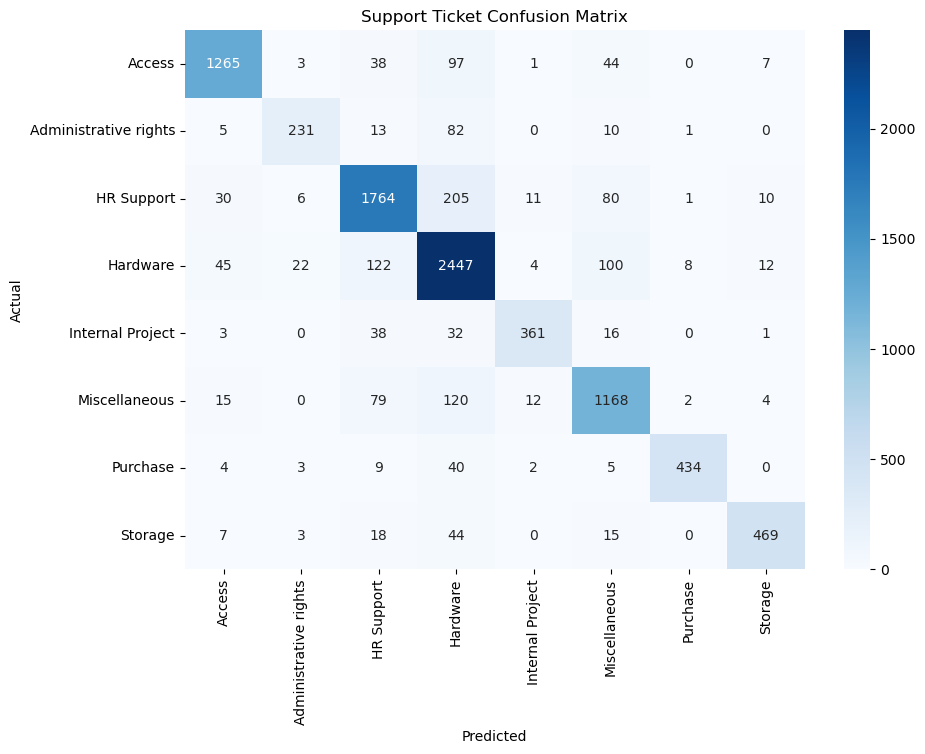

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Support Ticket Confusion Matrix')
plt.show()

# A fake ticket for testing
new_ticket = ["URGENT: My laptop screen is completely black and won't turn on!"]

# 1. Clean and vectorize the test ticket
clean_test = [clean_text(new_ticket[0])]
vector_test = tfidf.transform(clean_test)

# 2. Predict Category and Priority
pred_category = model.predict(vector_test)[0]
pred_priority = assign_priority(new_ticket[0])

print(f"Ticket: {new_ticket[0]}")
print(f"AI Category: {pred_category}")
print(f"System Priority: {pred_priority}")